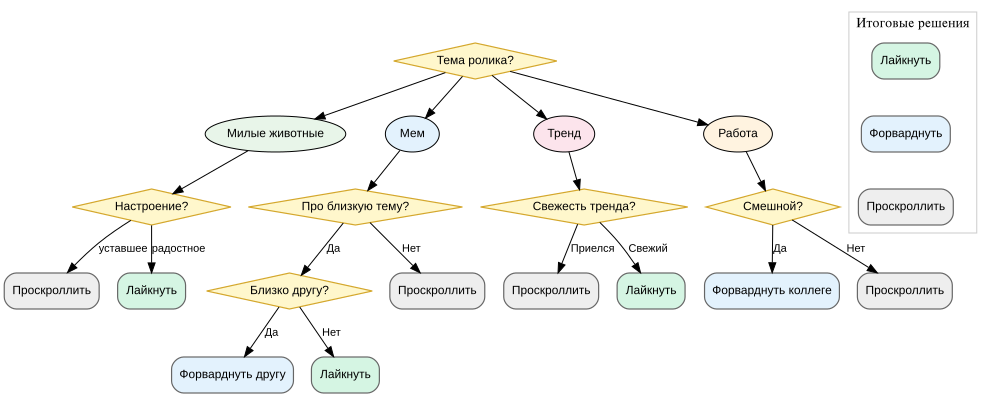

In [1]:
from graphviz import Digraph

# Создаём ориентированный граф
G = Digraph('ReelsDecisionTree', filename='reels_decision_tree', format='png')
G.attr(splines='spline', bgcolor='white')
G.attr('node', fontname='Arial', fontsize='12')
G.attr('edge', fontname='Arial', fontsize='11')

# Хелперы для узлов
def decision(node_id: str, label: str):
    """Узел-решение (вопрос)."""
    G.node(node_id, label, shape='diamond', style='filled', fillcolor='#FFF7CC', color='#D4A72C', penwidth='1.2')


def outcome(node_id: str, label: str, fill: str):
    """Узел-выход (действие).
    fill — цвет фона для различения действий
    """
    G.node(node_id, label, shape='box', style='rounded,filled', fillcolor=fill, color='#666666', penwidth='1.2')

# Корневой вопрос
decision('root', 'Тема ролика?')

# Первые ветки (категории контента)
G.node('cat', 'Милые животные', shape='oval', style='filled', fillcolor='#E8F5E9')
G.node('meme', 'Мем', shape='oval', style='filled', fillcolor='#E3F2FD')
G.node('trend', 'Тренд', shape='oval', style='filled', fillcolor='#FCE4EC')
G.node('work', 'Работа', shape='oval', style='filled', fillcolor='#FFF3E0')

G.edge('root', 'cat')
G.edge('root', 'meme')
G.edge('root', 'trend')
G.edge('root', 'work')

# Ветки «Животные»
decision('cat_mood', 'Настроение?')
G.edge('cat', 'cat_mood')

outcome('scroll_animals', 'Проскроллить', '#EEEEEE')
outcome('like_animals', 'Лайкнуть', '#D5F5E3')

G.edge('cat_mood', 'scroll_animals', label='уставшее')
G.edge('cat_mood', 'like_animals', label='радостное')

# Ветка «Мем»
decision('meme_rel', 'Про близкую тему?')
G.edge('meme', 'meme_rel')

decision('meme_rel_friend', 'Близко другу?')

outcome('share_meme', 'Форварднуть другу', '#E3F2FD')
outcome('like_meme',  'Лайкнуть', '#D5F5E3')
outcome('scroll_meme',  'Проскроллить', '#EEEEEE')

G.edge('meme_rel', 'meme_rel_friend', label='Да')
G.edge('meme_rel_friend', 'share_meme', label='Да')
G.edge('meme_rel_friend', 'like_meme', label='Нет')
G.edge('meme_rel', 'scroll_meme',  label='Нет')

# Ветка «Тренд»
decision('trend_fresh', 'Свежесть тренда?')
G.edge('trend', 'trend_fresh')

outcome('scroll_trend', 'Проскроллить', '#EEEEEE')
outcome('like_trend',   'Лайкнуть',     '#D5F5E3')

G.edge('trend_fresh', 'scroll_trend', label='Приелся')
G.edge('trend_fresh', 'like_trend',   label='Свежий')

# Ветка «Работа»
decision('work_value', 'Смешной?')
G.edge('work', 'work_value')

outcome('forward_work',   'Форварднуть коллеге', '#E3F2FD')
outcome('scroll_work', 'Проскроллить', '#EEEEEE')

G.edge('work_value', 'forward_work',   label='Да')
G.edge('work_value', 'scroll_work', label='Нет')

# (Необязательно) Легенда
with G.subgraph(name='cluster_legend') as c:
    c.attr(label='Итоговые решения', color='#CCCCCC')
    outcome('leg_like',  'Лайкнуть', '#D5F5E3')
    outcome('leg_share', 'Форварднуть', '#E3F2FD')
    outcome('leg_skip',  'Проскроллить', '#EEEEEE')
    c.attr('edge', style='invis')
    c.edge('leg_like', 'leg_share')
    c.edge('leg_share', 'leg_skip')

# Рендер
G.render(cleanup=True)
G